## GP Hyperparameter Optimization

First, configure `JAX` to run on your available hardware (using the `cpu` or `gpu`)

In [1]:
import jax
jax.config.update("jax_enable_x64", True)
jax.config.update("jax_platforms", "cuda")
_ = jax.devices("cuda")

In [ ]:
import os
import sys
import tqdm
import corner
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
sys.path.append("../src_jax")
from starspot import LightcurveModel
from gp_solver import GPSolver

results_dir = "results/"
if not os.path.exists(results_dir):
    os.makedirs(results_dir)

### Generate synthetic lightcurve data

Generated synthetic lightcurve with 400 observations.


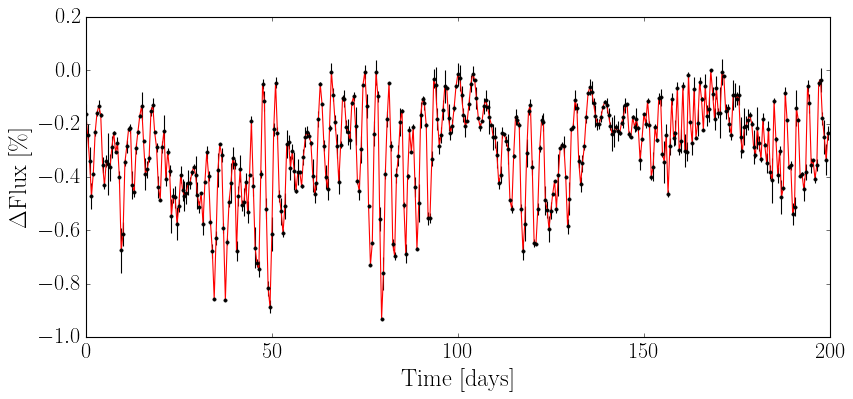

In [ ]:
tsim = 200
tsamp = 0.5
nspot_per_day = 0.25
nspot = int(tsim * nspot_per_day)

# True parameters — use nspot_rate (spots/day) for correct kernel amplitude
# nspot is passed separately to LightcurveModel (total count for the simulation)
theta_full = dict(peq=3.0, kappa=0.3, inc=np.pi/3, nspot_rate=nspot_per_day,
                  lspot=15.0, tau=6.0, alpha_max=0.05, fspot=0.)

lc = LightcurveModel(peq=theta_full['peq'], kappa=theta_full['kappa'],
                     inc=theta_full['inc'], nspot=nspot,
                     lspot=theta_full['lspot'], tau=theta_full['tau'],
                     alpha_max=theta_full['alpha_max'], fspot=theta_full['fspot'],
                     tsim=tsim, tsamp=tsamp, lat=[-np.pi/2, np.pi/2], long=[0, 2*np.pi])
tobs = lc.t
flux = lc.flux
flux_err = np.abs(np.random.normal(0, 0.2*np.std(lc.flux), lc.flux.shape))

print(f"Generated synthetic lightcurve with {len(tobs)} observations.")
plt.figure(figsize=[12,5])
plt.errorbar(tobs, flux*100 - 100, yerr=flux_err*100, fmt=".k", capsize=0)
plt.plot(tobs, lc.flux*100 - 100, "r-")
plt.xlabel("Time [days]", fontsize=22)
plt.ylabel(r"$\Delta$Flux [\%]", fontsize=22)
plt.savefig(os.path.join(results_dir, "synthetic_lightcurve.png"), dpi=300)
plt.show()

### Set up optimization bounds and initialize GP

In [9]:
bounds = {
    "peq":      (1.0, 5.0),
    "kappa":    (-1.0, 1.0),
    "inc":      (0.0, np.pi/2),
    "lspot":    (10.0, 20.0),
    "tau":      (0.1, 10.0),
    "sigma_k":  (1e-5, 0.1),   # physical (not log) — required by fit_acf
}

gp = GPSolver(tobs, flux, flux_err, theta_full, bounds=bounds, matrix_solver="cholesky_banded")
theta_true = gp.get_theta()
print(f"True parameters: {theta_true}\n")

Banded Cholesky: bandwidth=80, N=400, sparsity=79.8%
True parameters: {'peq': 3.0, 'kappa': 0.3, 'inc': 1.0471975511965976, 'lspot': 15.0, 'tau': 6.0, 'sigma_k': 0.0012500000000000002}



### Example 1: MAP solution

In [12]:
map_keys = list(bounds.keys())
theta_maps = []
vals_maps = []
print("\nFinding map fit solution...")
for _ in tqdm.tqdm(range(5)):
    theta_opt, result = gp.find_map(keys=map_keys, method="nelder-mead")
    theta_maps.append(theta_opt)
    vals_maps.append(result.fun)
theta_map = theta_maps[np.argmin(vals_maps)]
print(f"map fit solution: {theta_map}\n")
np.savez(os.path.join(results_dir, "map_fit_results.npz"), theta_map=theta_map, theta_true=theta_true)


Finding map fit solution...


100%|██████████| 5/5 [00:42<00:00,  8.44s/it]

map fit solution: {'peq': 2.96632240687033, 'kappa': 0.3150660356427166, 'inc': 1.1529746248973984, 'lspot': 16.29057707291782, 'tau': 4.211439186380059, 'sigma_k': 0.0010992087860904995}



Reload best fit results (if already run):

In [20]:
map_res = np.load(os.path.join(results_dir, "map_fit_results.npz"), allow_pickle=True)
theta_map = map_res["theta_map"].item()
theta_true = map_res["theta_true"].item()

pd.DataFrame([theta_true, theta_map], index=["True", "MAP Fit"], columns=theta_true.keys())

,peq,kappa,inc,lspot,tau,sigma_k
True,3.000000,0.300000,1.047198,15.000000,6.000000,0.001250
MAP Fit,2.966322,0.315066,1.152975,16.290577,4.211439,0.001099


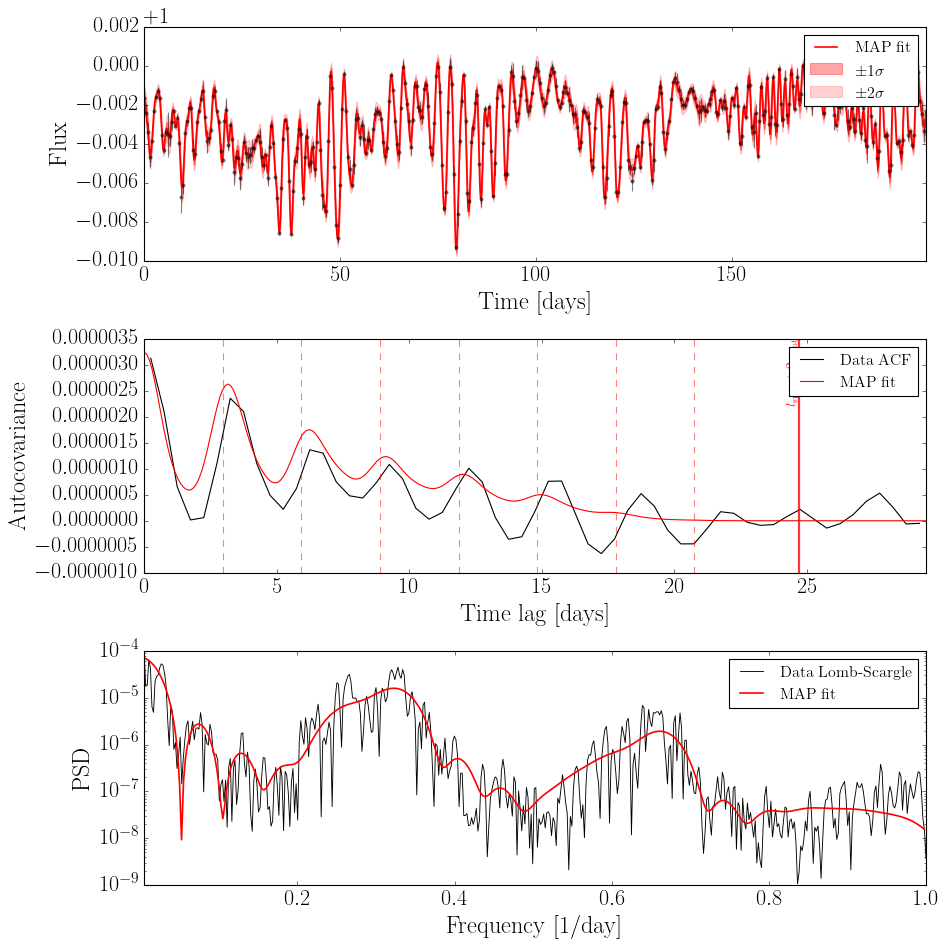

In [21]:
tlag_plot = np.arange(0, 30, tsamp)

fig, axes = plt.subplots(3, 1, figsize=(12, 12))

gp.plot_prediction(theta=theta_map, ax=axes[0], model_color="r", model_label="MAP fit", data_label=None)
gp.plot_acf(theta=theta_map, ax=axes[1], tlags=tlag_plot, model_color="r", model_label="MAP fit")
gp.plot_psd(theta=theta_map, ax=axes[2], model_color="r", model_label="MAP fit")

t_envelope = theta_map["lspot"] + 2 * theta_map["tau"]
for ii in range(int(t_envelope / theta_map["peq"])):
    axes[1].axvline(ii * theta_map["peq"], color="r", alpha=0.5, ls="--")
axes[1].axvline(t_envelope, color="r", alpha=0.8, linewidth=2, label="Envelope")
axes[1].text(t_envelope, 1.0, r"$l_{\rm spot} + 2\tau_{\rm spot}$",
             color="r", rotation=90, va="top", ha="right", fontsize=12,
             transform=axes[1].get_xaxis_transform())

fig.tight_layout()
fig.savefig(os.path.join(results_dir, "map_fit.png"), dpi=150)
plt.show(fig)

### Example 2: ACF fit

In [10]:
acf_keys = list(bounds.keys())
theta_acfs = []
vals_acfs = []
print("\nFinding ACF fit solution...")
for _ in tqdm.tqdm(range(5)):
    theta_opt, result = gp.fit_acf(keys=acf_keys, method="nelder-mead")
    theta_acfs.append(theta_opt)
    vals_acfs.append(result.fun)
theta_acf = theta_acfs[np.argmin(vals_acfs)]
print(f"ACF fit solution: {theta_acf}\n")
np.savez(os.path.join(results_dir, "acf_fit_results.npz"), theta_acf=theta_acf, theta_true=theta_true)


Finding ACF fit solution...


100%|██████████| 5/5 [00:11<00:00,  2.25s/it]

ACF fit solution: {'peq': 3.0691652429870198, 'kappa': 1.0226614094389364, 'inc': 1.3942356115680443, 'lspot': 17.038549651433186, 'tau': -0.9559779561390492, 'sigma_k': 0.0012341677746610792}



In [22]:
acf_res = np.load(os.path.join(results_dir, "acf_fit_results.npz"), allow_pickle=True)
theta_acf = acf_res["theta_acf"].item()
theta_true = acf_res["theta_true"].item()

pd.DataFrame([theta_true, theta_acf], index=["True", "ACF Fit"], columns=theta_true.keys())

,peq,kappa,inc,lspot,tau,sigma_k
True,3.000000,0.300000,1.047198,15.00000,6.000000,0.001250
ACF Fit,3.069165,1.022661,1.394236,17.03855,-0.955978,0.001234


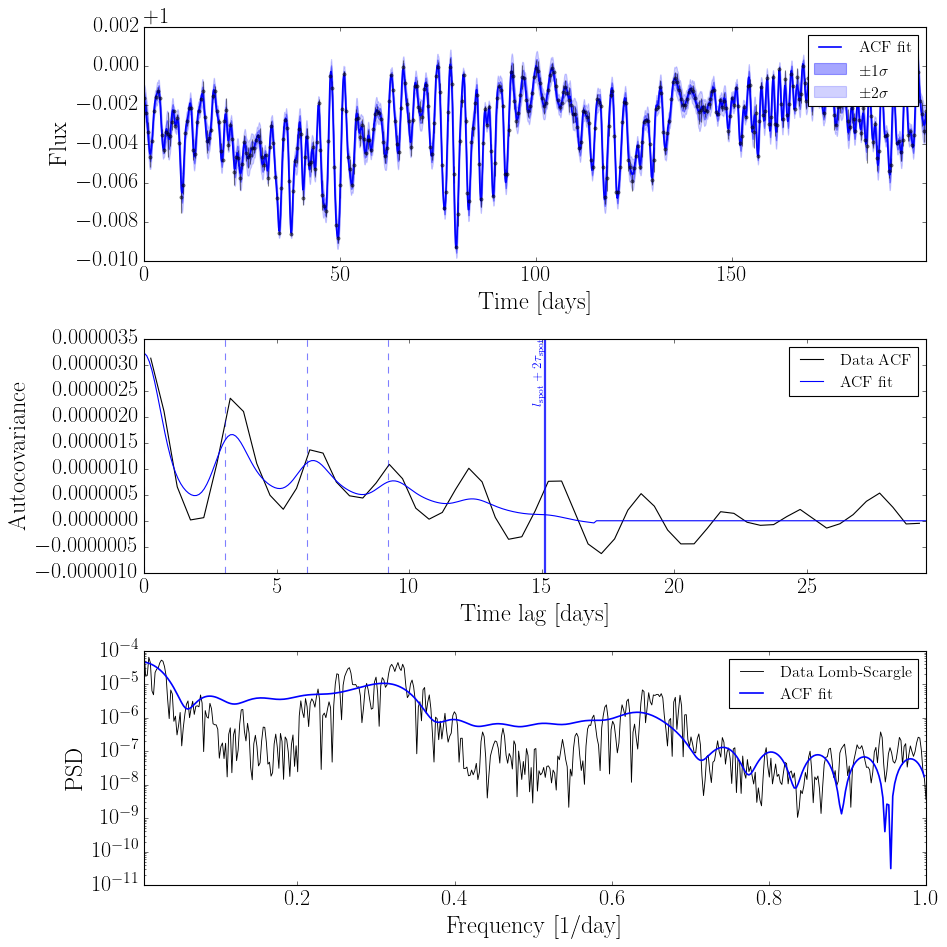

In [11]:
tlag_plot = np.arange(0, 30, tsamp)

fig, axes = plt.subplots(3, 1, figsize=(12, 12))

gp.plot_prediction(theta=theta_acf, ax=axes[0], model_color="b", model_label="ACF fit", data_label=None)
gp.plot_acf(theta=theta_acf, ax=axes[1], tlags=tlag_plot, model_color="b", model_label="ACF fit")
gp.plot_psd(theta=theta_acf, ax=axes[2], model_color="b", model_label="ACF fit")

t_envelope = theta_acf["lspot"] + 2 * theta_acf["tau"]
for ii in range(int(t_envelope / theta_acf["peq"])):
    axes[1].axvline(ii * theta_acf["peq"], color="b", alpha=0.5, ls="--")
axes[1].axvline(t_envelope, color="b", alpha=0.8, linewidth=2, label="Envelope")
axes[1].text(t_envelope, 1.0, r"$l_{\rm spot} + 2\tau_{\rm spot}$",
             color="b", rotation=90, va="top", ha="right", fontsize=12,
             transform=axes[1].get_xaxis_transform())

fig.tight_layout()
fig.savefig(os.path.join(results_dir, "kernel_fit.png"), dpi=150)
plt.show(fig)